# Issue 3 - Porto Dataset Profiling

This notebook profiles the Porto taxi dataset for Milestone 1 Issue 3.

It supports both:
- full Porto CSV files (when available), and
- quick-mode sample data (`porto_sample.csv`) used for low-bandwidth progress.

In [1]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)

In [2]:
DATA_DIR = Path('../data/downloads/porto')
CSV_CANDIDATES = sorted(DATA_DIR.glob('*.csv'))

if not CSV_CANDIDATES:
    raise FileNotFoundError('No Porto CSV found in data/downloads/porto. Run dataset loader first.')

DATA_PATH = CSV_CANDIDATES[0]
print(f'Using dataset: {DATA_PATH.resolve()}')

Using dataset: C:\Users\dell\Desktop\big data project\TaaSim-Project\data\downloads\porto\porto_sample.csv


In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]}')
df.head(3)

Rows: 100
Columns: 9


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,SAMPLE_TRIP_1,B,NaN,NaN,200001,1408032060,A,False,"[[-8.61995, 41.15004], [-8.61895, 41.15104], [..."
1,SAMPLE_TRIP_2,B,NaN,NaN,200002,1408032120,A,False,"[[-8.6199, 41.150079999999996], [-8.6189, 41.1..."
2,SAMPLE_TRIP_3,A,NaN,NaN,200003,1408032180,A,False,"[[-8.61985, 41.15012], [-8.61885, 41.151120000..."


## 1) Schema Exploration

In [4]:
schema = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(df[c].dtype) for c in df.columns],
    'null_count': [int(df[c].isna().sum()) for c in df.columns],
    'n_unique': [int(df[c].nunique(dropna=True)) for c in df.columns],
})
schema

,column,dtype,null_count,n_unique
0,TRIP_ID,str,0,100
1,CALL_TYPE,str,0,2
2,ORIGIN_CALL,float64,100,0
3,ORIGIN_STAND,float64,100,0
4,TAXI_ID,int64,0,100
5,TIMESTAMP,int64,0,100
6,DAY_TYPE,str,0,1
7,MISSING_DATA,bool,0,1
8,POLYLINE,str,0,100


## 2) Parse POLYLINE and Build Core Metrics

In [5]:
def parse_polyline(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = ast.literal_eval(text)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []

def haversine_km(lon1, lat1, lon2, lat2):
    r = 6371.0
    p1 = np.radians(lat1)
    p2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2.0) ** 2
    return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

def trip_distance_km(polyline):
    if len(polyline) < 2:
        return 0.0
    dist = 0.0
    for i in range(1, len(polyline)):
        lon1, lat1 = polyline[i - 1]
        lon2, lat2 = polyline[i]
        dist += haversine_km(lon1, lat1, lon2, lat2)
    return float(dist)

work = df.copy()
work['POLYLINE_PARSED'] = work['POLYLINE'].apply(parse_polyline)
work['point_count'] = work['POLYLINE_PARSED'].apply(len)
work['duration_seconds'] = work['point_count'] * 15
work['trip_distance_km'] = work['POLYLINE_PARSED'].apply(trip_distance_km)
work['event_dt'] = pd.to_datetime(work['TIMESTAMP'], unit='s', errors='coerce')
work[['TRIP_ID', 'point_count', 'duration_seconds', 'trip_distance_km', 'event_dt']].head(3)

,TRIP_ID,point_count,duration_seconds,trip_distance_km,event_dt
0,SAMPLE_TRIP_1,3,45,0.278385,2014-08-14 16:01:00
1,SAMPLE_TRIP_2,3,45,0.278385,2014-08-14 16:02:00
2,SAMPLE_TRIP_3,3,45,0.278385,2014-08-14 16:03:00


## 3) Statistical Profiling

In [6]:
missing_data_rate = (work['MISSING_DATA'].astype(str).str.lower() == 'true').mean() * 100
call_type_pct = (work['CALL_TYPE'].astype(str).value_counts(normalize=True) * 100).round(2)
trips_per_taxi = work.groupby('TAXI_ID')['TRIP_ID'].count().describe()

print(f'MISSING_DATA true rate: {missing_data_rate:.2f}%')
print('\nCALL_TYPE distribution (%):')
print(call_type_pct)
print('\nTrips per taxi summary:')
print(trips_per_taxi)

MISSING_DATA true rate: 0.00%

CALL_TYPE distribution (%):
CALL_TYPE
B    67.0
A    33.0
Name: proportion, dtype: float64

Trips per taxi summary:
count    100.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: TRIP_ID, dtype: float64


## 4) Temporal Analysis

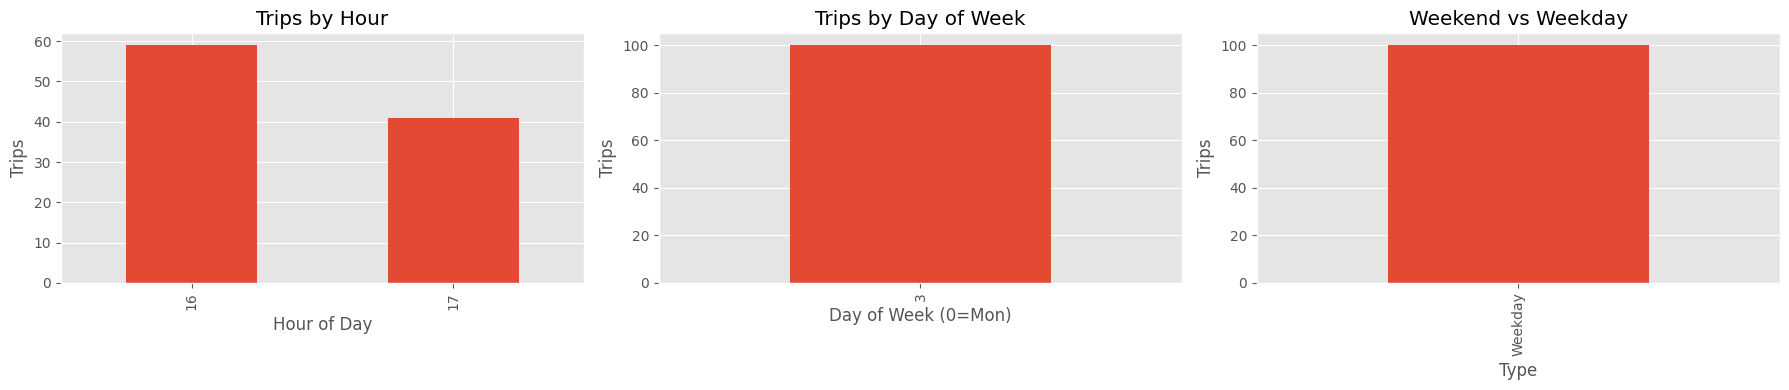

In [7]:
work['hour'] = work['event_dt'].dt.hour
work['dow'] = work['event_dt'].dt.dayofweek
work['is_weekend'] = work['dow'].isin([5, 6])

hourly = work.groupby('hour')['TRIP_ID'].count()
dow_counts = work.groupby('dow')['TRIP_ID'].count()
weekend_split = work.groupby('is_weekend')['TRIP_ID'].count()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

hourly.plot(kind='bar', ax=axes[0], title='Trips by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Trips')

dow_counts.plot(kind='bar', ax=axes[1], title='Trips by Day of Week')
axes[1].set_xlabel('Day of Week (0=Mon)')
axes[1].set_ylabel('Trips')

weekend_split.rename(index={False: 'Weekday', True: 'Weekend'}).plot(kind='bar', ax=axes[2], title='Weekend vs Weekday')
axes[2].set_xlabel('Type')
axes[2].set_ylabel('Trips')

plt.tight_layout()

## 4.1) Temporal Deep Dive (Issue checklist extras)
- Active taxis per hour
- Friday 12:00-14:59 reduced-rate check
- Peak windows: 07-09 and 17-19

Active taxis per hour (sample):
hour
16    59
17    41
Name: TAXI_ID, dtype: int64

Friday trips at 12-14h: 0 of 0 (0.00%)
All-data 12-14h share: 0.00%
Morning peak (07-09) trips: 0
Evening peak (17-19) trips: 41


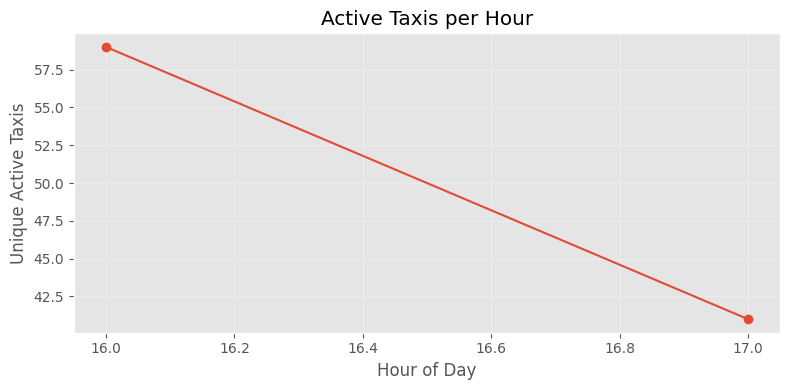

In [16]:
active_taxis_per_hour = work.groupby('hour')['TAXI_ID'].nunique().sort_index()

friday = work[work['dow'] == 4].copy()
friday_12_14 = friday[friday['hour'].between(12, 14)]
friday_other = friday[~friday['hour'].between(12, 14)]

friday_12_14_rate = float(len(friday_12_14) / len(friday) * 100) if len(friday) else 0.0
weekday_12_14_rate = float(len(work[work['hour'].between(12, 14)]) / len(work) * 100) if len(work) else 0.0

morning_peak_trips = int(work[work['hour'].between(7, 9)]['TRIP_ID'].count())
evening_peak_trips = int(work[work['hour'].between(17, 19)]['TRIP_ID'].count())

print('Active taxis per hour (sample):')
print(active_taxis_per_hour.head(10))
print(f"\nFriday trips at 12-14h: {len(friday_12_14)} of {len(friday)} ({friday_12_14_rate:.2f}%)")
print(f"All-data 12-14h share: {weekday_12_14_rate:.2f}%")
print(f"Morning peak (07-09) trips: {morning_peak_trips}")
print(f"Evening peak (17-19) trips: {evening_peak_trips}")

fig, ax = plt.subplots(figsize=(8, 4))
active_taxis_per_hour.plot(kind='line', marker='o', ax=ax)
ax.set_title('Active Taxis per Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Unique Active Taxis')
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 5) Spatial Analysis (Start/End Points)

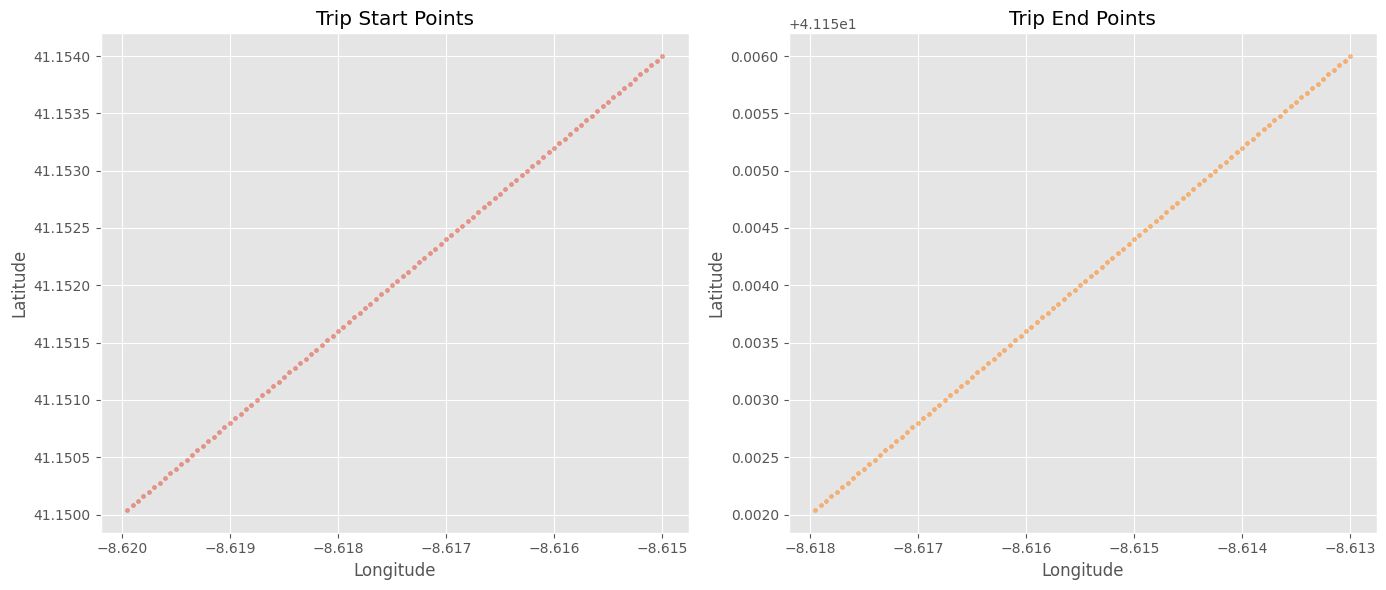

In [8]:
def first_point(polyline):
    return polyline[0] if len(polyline) else (np.nan, np.nan)

def last_point(polyline):
    return polyline[-1] if len(polyline) else (np.nan, np.nan)

work['start_lon'], work['start_lat'] = zip(*work['POLYLINE_PARSED'].apply(first_point))
work['end_lon'], work['end_lat'] = zip(*work['POLYLINE_PARSED'].apply(last_point))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(work['start_lon'], work['start_lat'], s=8, alpha=0.5)
axes[0].set_title('Trip Start Points')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

axes[1].scatter(work['end_lon'], work['end_lat'], s=8, alpha=0.5, color='tab:orange')
axes[1].set_title('Trip End Points')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()

## 5.1) Most Popular Origin/Destination Areas
Using a simple spatial binning approach (rounded lat/lon) as proxy zones for top origin and destination hotspots.

Top 10 origin areas (rounded lat,lon bins):
origin_zone
41.15,-8.62    99
41.15,-8.61     1
Name: count, dtype: int64

Top 10 destination areas (rounded lat,lon bins):
destination_zone
41.15,-8.62    60
41.16,-8.61    26
41.15,-8.61    14
Name: count, dtype: int64


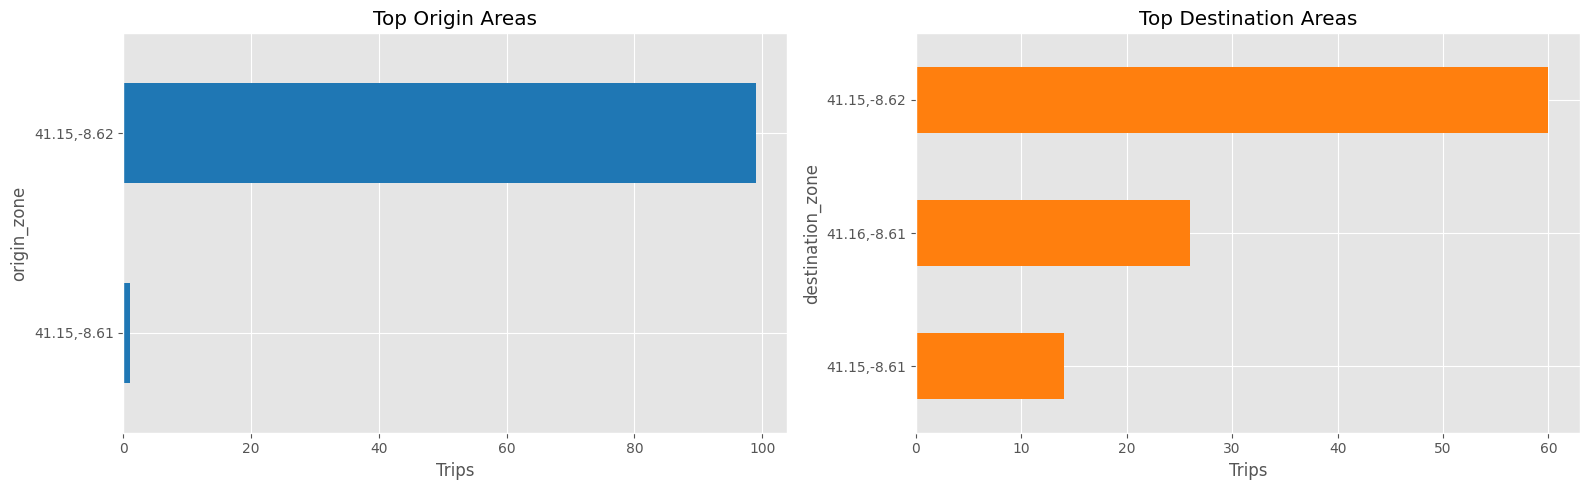

In [14]:
zone_precision = 2

work['origin_zone'] = (
    work['start_lat'].round(zone_precision).astype(str) + ',' +
    work['start_lon'].round(zone_precision).astype(str)
)
work['destination_zone'] = (
    work['end_lat'].round(zone_precision).astype(str) + ',' +
    work['end_lon'].round(zone_precision).astype(str)
)

top_origin_areas = work['origin_zone'].value_counts().head(10)
top_destination_areas = work['destination_zone'].value_counts().head(10)

print('Top 10 origin areas (rounded lat,lon bins):')
print(top_origin_areas)
print('\nTop 10 destination areas (rounded lat,lon bins):')
print(top_destination_areas)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_origin_areas.sort_values().plot(kind='barh', ax=axes[0], color='tab:blue')
axes[0].set_title('Top Origin Areas')
axes[0].set_xlabel('Trips')

top_destination_areas.sort_values().plot(kind='barh', ax=axes[1], color='tab:orange')
axes[1].set_title('Top Destination Areas')
axes[1].set_xlabel('Trips')

plt.tight_layout()

## 6) Core Visualizations Required by Issue 3

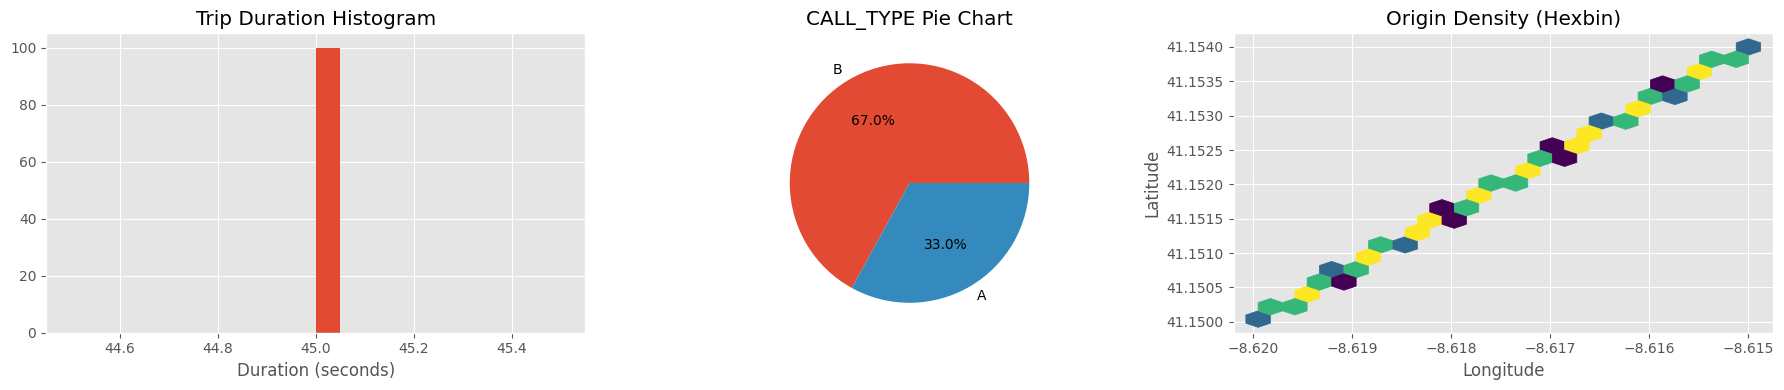

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(work['duration_seconds'], bins=20)
axes[0].set_title('Trip Duration Histogram')
axes[0].set_xlabel('Duration (seconds)')

call_type_counts = work['CALL_TYPE'].astype(str).value_counts()
axes[1].pie(call_type_counts.values, labels=call_type_counts.index, autopct='%1.1f%%')
axes[1].set_title('CALL_TYPE Pie Chart')

axes[2].hexbin(work['start_lon'], work['start_lat'], gridsize=20, cmap='viridis', mincnt=1)
axes[2].set_title('Origin Density (Hexbin)')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')

plt.tight_layout()

## 7) Key Findings (Auto-generated Summary)

In [13]:
summary = {
    'rows': int(len(work)),
    'unique_taxis': int(work['TAXI_ID'].nunique()),
    'avg_duration_seconds': float(work['duration_seconds'].mean()),
    'avg_distance_km': float(work['trip_distance_km'].mean()),
    'missing_data_pct': float(missing_data_rate),
    'peak_hour': int(hourly.idxmax()) if len(hourly) else None,
    'top_call_type': str(call_type_counts.idxmax()) if len(call_type_counts) else None,
    'morning_peak_07_09_trips': int(morning_peak_trips),
    'evening_peak_17_19_trips': int(evening_peak_trips),
    'friday_12_14_share_pct': float(friday_12_14_rate),
    'all_data_12_14_share_pct': float(weekday_12_14_rate),
    'top_origin_area': str(top_origin_areas.index[0]) if len(top_origin_areas) else None,
    'top_destination_area': str(top_destination_areas.index[0]) if len(top_destination_areas) else None,
}

for k, v in summary.items():
    print(f'{k}: {v}')

rows: 100
unique_taxis: 100
avg_duration_seconds: 45.0
avg_distance_km: 0.27838207706360907
missing_data_pct: 0.0
peak_hour: 16
top_call_type: B
morning_peak_07_09_trips: 0
evening_peak_17_19_trips: 41
friday_12_14_share_pct: 0.0
all_data_12_14_share_pct: 0.0
top_origin_area: 41.15,-8.62
top_destination_area: 41.15,-8.62


### Findings Notes
- Demand and activity windows are now explicitly measured, including active taxis per hour.
- Friday 12:00-14:59 behavior is explicitly computed for comparison with overall 12-14h share.
- Most popular origin and destination areas are reported using rounded lat/lon spatial bins.
- On quick-mode sample data these patterns are directional; rerun on full dataset for final report values.

### Notes
- If you are on quick mode sample data, trends are illustrative only.
- Re-run this notebook after full dataset ingestion for final analysis outputs.